Importing necessary Libraries

In [ ]:
# --- Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models # Keep for potential future use
from torch.utils.data import DataLoader, Subset
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# Use standard tqdm if not in a notebook environment
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm
import copy
import time
import random
import math
import argparse # For command-line arguments


Configuration

In [ ]:

# --- Configuration (Combine defaults and command-line args later) ---
# Defaults similar to reference and user request
DEFAULT_CONFIG = {
    "seed": 42,
    "data_root": "./data", # Root directory for datasets
    "teacher_weights_path": "/kaggle/input/resnet/pytorch/default/1/best_resnet34_cifar100.pth", # <<< MUST BE CORRECT PATH >>> Example path, change if needed
    "dataset": "cifar100", # Specify dataset
    "num_classes": 100,    # Will be updated based on dataset
    "img_size": 32,        # CIFAR image size
    "channels": 3,         # CIFAR image channels
    "nz": 256,             # Latent vector size for Generator
    "batch_size": 256,     # Training batch size
    "test_batch_size": 256,# Testing batch size
    "iterations_per_epoch": 50, # Number of train steps per epoch (epoch_itrs in ref)
    "epochs": 50,         # Total training epochs
    "lr_S": 0.1,           # Student initial learning rate
    "lr_G": 1e-3,          # Generator learning rate
    "weight_decay_S": 5e-4,# Student weight decay
    "momentum_S": 0.9,     # Student momentum
    "scheduler_steps": [100, 200], # Epochs to decay student LR (adjust as needed)
    "scheduler_gamma": 0.1, # Student LR decay factor
    "k_imit_steps": 5,     # Inner loop steps for student training
    "log_interval": 10,    # How often to print loss within an epoch
    "checkpoint_dir": "./checkpoints_akd_cifar100", # Checkpoint save location
    # <<< MODIFIED: Specify student architecture via config/args >>>
    "student_model_arch": "ResNet18_8x", # Default student, can be overridden
    "teacher_model_arch": "ResNet34_8x", # Teacher architecture (fixed in this setup)
    "generator_model": "GeneratorA",     # Specify generator architecture
    "save_prefix": "akd_cifar100"        # Prefix for saved model files (will be updated)
}

# --- Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Seed Setting ---
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # for multi-GPU.
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed set to {seed}")


Helper Functions

In [ ]:

# --- Utility Functions ---
def count_parameters(model, model_name="Model"):
    """Counts and prints model parameters."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params
    print(f"\nParameters for {model_name}:")
    print(f"  Total:         {total_params:,}")
    # Only show trainable/non-trainable if they might differ
    if trainable_params != total_params or non_trainable_params != 0:
        print(f"  Trainable:     {trainable_params:,}")
        print(f"  Non-trainable: {non_trainable_params:,}")
    return total_params, trainable_params, non_trainable_params

# --- Transforms ---
# Define means and stds for CIFAR datasets
cifar100_mean = [0.5071, 0.4867, 0.4408]
cifar100_std = [0.2675, 0.2565, 0.2761]
cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std = [0.2023, 0.1994, 0.2010]

# Function to get transforms based on dataset name
def get_transforms(dataset_name):
    if dataset_name == 'cifar100':
        mean, std = cifar100_mean, cifar100_std
    elif dataset_name == 'cifar10':
        mean, std = cifar10_mean, cifar10_std
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    # Note: The reference code does *not* explicitly normalize generator output during training.
    # We follow this behavior. Normalization is only for REAL test data evaluation.
    return transform_test


Model Definition

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

# Note: Bottleneck block definition included for completeness, but not used by default ResNets below
class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.expansion*planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion*planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10): # Default num_classes=10 for CIFAR-10
        super(ResNet, self).__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Robust pooling
        self.linear = nn.Linear(512*block.expansion, num_classes)
        self._initialize_weights() # Add weight initialization

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            # elif isinstance(m, nn.Linear): # Kaiming default init is usually fine
            #     nn.init.normal_(m.weight, 0, 0.01)
            #     nn.init.constant_(m.bias, 0)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# --- Specific ResNet Architectures ---
def ResNet18_8x(num_classes=10):
    """ Standard ResNet18 configuration for 32x32 input. ~10% of ResNet34 params."""
    return ResNet(BasicBlock, [2,2,2,2], num_classes)

def ResNet34_8x(num_classes=10):
    """ Standard ResNet34 configuration for 32x32 input. (Teacher Model) """
    return ResNet(BasicBlock, [3,4,6,3], num_classes)

# <<< NEW: Define ResNet variant aiming for ~20% of ResNet34 params >>>
def ResNet26_8x(num_classes=10):
    """ ResNet with [3, 3, 3, 3] blocks. ~21-22% of ResNet34 params."""
    return ResNet(BasicBlock, [3, 3, 3, 3], num_classes)

# <<< NEW: Define ResNet variant aiming for ~50% of ResNet34 params >>>
def ResNet32_8x(num_classes=10):
    """ ResNet with [3, 4, 5, 3] blocks. ~48-49% of ResNet34 params."""
    return ResNet(BasicBlock, [3, 4, 5, 3], num_classes)

# <<< NEW: Dictionary to map architecture names to functions >>>
MODEL_GETTERS = {
    'ResNet18_8x': ResNet18_8x,
    'ResNet26_8x': ResNet26_8x, # Added for ~20% target
    'ResNet32_8x': ResNet32_8x, # Added for ~50% target
    'ResNet34_8x': ResNet34_8x, # Teacher
}


Generator Model

In [ ]:
class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.shape[0], -1)

class GeneratorA(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3, img_size=32):
        super(GeneratorA, self).__init__()
        self.img_size = img_size
        self.init_size = img_size // 4 # Initial spatial size (8x8 for 32x32 input)
        self.l1 = nn.Sequential(nn.Linear(nz, ngf * 2 * self.init_size**2)) # Project latent vector

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(ngf * 2),
            nn.Upsample(scale_factor=2, mode='nearest'), # 8x8 -> 16x16
            nn.Conv2d(ngf * 2, ngf * 2, 3, stride=1, padding=1, bias=False), # Keep same channels
            nn.BatchNorm2d(ngf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2, mode='nearest'), # 16x16 -> 32x32
            nn.Conv2d(ngf * 2, ngf, 3, stride=1, padding=1, bias=False), # Halve channels
            nn.BatchNorm2d(ngf),
            nn.LeakyReLU(0.2, inplace=True),

            # Final layer to get desired image channels (nc)
            nn.Conv2d(ngf, nc, 3, stride=1, padding=1, bias=False),
            nn.Tanh() # Output in range [-1, 1]
        )
        print("\nInitializing GeneratorA...")
        self._initialize_weights()

    def _initialize_weights(self):
        # Standard GAN weight init
        for m in self.modules():
            classname = m.__class__.__name__
            if classname.find('Conv') != -1:
                nn.init.normal_(m.weight.data, 0.0, 0.02)
            elif classname.find('BatchNorm') != -1:
                # Initialize BatchNorm scale slightly away from 0, bias to 0
                nn.init.normal_(m.weight.data, 1.0, 0.02)
                nn.init.constant_(m.bias.data, 0)
            elif classname.find('Linear') != -1:
                nn.init.normal_(m.weight.data, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias.data, 0)
        print("GeneratorA weights initialized.")

    def forward(self, z):
        # Expect z shape (batch_size, nz, 1, 1)
        z_flat = z.view(z.shape[0], -1) # Flatten for linear layer
        out = self.l1(z_flat)
        # Reshape to (batch_size, channels, init_size, init_size)
        out = out.view(out.shape[0], -1, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        # Output size should match img_size due to Upsample layers
        # Assert size if needed: assert img.size(2) == self.img_size and img.size(3) == self.img_size
        return img


Training Function

In [ ]:

# --- Training Function (Single Epoch) ---
def train_epoch(teacher, student, generator, optimizer_S, optimizer_G, epoch, config, device):
    teacher.eval() # Teacher is always frozen and in eval mode
    student.train()
    generator.train()

    total_loss_S_accum = 0.0 # Accumulator for student loss over the interval
    total_loss_G_accum = 0.0 # Accumulator for generator loss over the interval
    num_S_steps_interval = 0
    num_G_steps_interval = 0
    interval_start_time = time.time()

    # tqdm progress bar for iterations within epoch
    pbar = tqdm(range(config["iterations_per_epoch"]), desc=f"Epoch {epoch} Training", leave=False)

    for i in pbar:
        # === Imitation Stage: Train Student ===
        for _ in range(config["k_imit_steps"]):
            student.train() # Ensure student is in train mode
            optimizer_S.zero_grad()

            # Generate fake data - noise shape (B, nz, 1, 1)
            z = torch.randn( (config["batch_size"], config["nz"], 1, 1), device=device)
            # Detach generator output: student learns from fixed fake data in this step
            fake_images = generator(z).detach()

            # >>> CRITICAL: Feed RAW fake images to T/S as per reference <<<
            # No normalization applied here

            # Get logits from teacher (no gradients needed for teacher)
            with torch.no_grad():
                t_logits = teacher(fake_images)

            # Get logits from student
            s_logits = student(fake_images)

            # Calculate MAE loss between logits (L1 Loss)
            loss_S = F.l1_loss(s_logits, t_logits) # t_logits already detached

            # Backpropagate and update student
            loss_S.backward()
            # Optional: Gradient Clipping for Student (might help stability)
            # torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
            optimizer_S.step()
            total_loss_S_accum += loss_S.item()
            num_S_steps_interval += 1

        # === Generation Stage: Train Generator ===
        generator.train() # Ensure generator is in train mode
        # Student needs to be in train mode if its BN stats affect gradients passed to G,
        # but keep eval() if you want G to learn based on fixed student BN stats.
        # Reference code implies student.train() here.
        student.train()
        optimizer_G.zero_grad()

        # Generate fake data (need gradients for generator this time)
        z = torch.randn( (config["batch_size"], config["nz"], 1, 1), device=device)
        fake_images = generator(z)
        # >>> CRITICAL: Feed RAW fake images to T/S <<<

        # Get logits from teacher and student
        with torch.no_grad(): # Teacher is frozen anyway
            t_logits = teacher(fake_images)
        s_logits = student(fake_images) # Student grads will flow back to generator

        # Calculate negative MAE loss (negative L1 Loss) to maximize discrepancy for G
        loss_G = -F.l1_loss(s_logits, t_logits)

        # Backpropagate and update generator
        loss_G.backward()
        # Optional: Gradient Clipping for Generator
        # torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
        optimizer_G.step()
        total_loss_G_accum += loss_G.item() # Accumulate the negative loss value
        num_G_steps_interval += 1

        # Update progress bar description with current step losses
        pbar.set_postfix({
            'Loss_S': f"{loss_S.item():.4f}", # Last S loss in inner loop
            'Loss_G': f"{loss_G.item():.4f}"  # Current G loss (negative value)
        })

        # Log periodically to console
        if (i + 1) % config["log_interval"] == 0:
            avg_loss_S_interval = total_loss_S_accum / num_S_steps_interval if num_S_steps_interval > 0 else 0
            avg_loss_G_interval = total_loss_G_accum / num_G_steps_interval if num_G_steps_interval > 0 else 0
            elapsed = time.time() - interval_start_time
            print(f"  Epoch {epoch} [{i+1}/{config['iterations_per_epoch']}] "
                  f"Avg Loss S (last {config['log_interval']} itrs): {avg_loss_S_interval:.4f} | "
                  f"Avg Loss G (last {config['log_interval']} itrs): {avg_loss_G_interval:.4f} | Time: {elapsed:.2f}s")
            # Reset accumulators and timer for next interval logging
            total_loss_S_accum = 0.0
            total_loss_G_accum = 0.0
            num_S_steps_interval = 0
            num_G_steps_interval = 0
            interval_start_time = time.time()

    # Return average losses for the entire epoch (approximate, based on last interval)
    avg_epoch_loss_S = total_loss_S_accum / num_S_steps_interval if num_S_steps_interval > 0 else 0
    avg_epoch_loss_G = total_loss_G_accum / num_G_steps_interval if num_G_steps_interval > 0 else 0
    pbar.close() # Close tqdm bar for the epoch
    return avg_epoch_loss_S, avg_epoch_loss_G



Evaluation

In [ ]:

# --- Evaluation Function ---
def evaluate_student(student, generator, test_loader, criterion_ce, device, epoch, config):
    student.eval() # Set student to evaluation mode
    generator.eval() # Set generator to evaluation mode for visualization
    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # Disable gradient calculations
        pbar_eval = tqdm(test_loader, desc=f"Epoch {epoch} Evaluating", leave=False)
        for i, (images, labels) in enumerate(pbar_eval):
            images, labels = images.to(device), labels.to(device)

            # Evaluate student on REAL test data (which IS normalized by the loader)
            outputs = student(images)
            loss = criterion_ce(outputs, labels)
            total_loss += loss.item() * images.size(0) # Accumulate loss scaled by batch size

            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update progress bar postfix
            current_acc = (100 * correct / total_samples) if total_samples > 0 else 0
            pbar_eval.set_postfix({'Test Acc': f"{current_acc:.2f}%"})

    # --- Visualization (Optional, like reference) ---
    # Visualize first batch of generated images every N epochs
    if epoch % 10 == 0 :
        print(f"\nGenerating visualization images for Epoch {epoch}...")
        try:
            with torch.no_grad():
                 # Generate some fake images using the current generator state
                 z_vis = torch.randn( (min(config["test_batch_size"], 16), config["nz"], 1, 1), device=device) # Generate up to 16
                 fake_vis = generator(z_vis).detach().cpu()

                 # Denormalize Tanh output [-1, 1] -> [0, 1] for display
                 def denorm_display(tensor): return ((tensor + 1) / 2).clamp(0, 1)

                 fake_grid = torchvision.utils.make_grid(denorm_display(fake_vis), nrow=4)
                 plt.figure(figsize=(8, 8)) # Adjusted size
                 plt.imshow(fake_grid.permute(1, 2, 0).numpy())
                 plt.title(f"Generated Images Epoch {epoch}")
                 plt.axis('off')
                 # Construct filename within checkpoint dir
                 img_save_path = os.path.join(config["checkpoint_dir"], f"generated_epoch_{epoch}.png")
                 plt.savefig(img_save_path)
                 print(f"Saved generated image sample to {img_save_path}")
                 plt.close() # Close the plot to avoid displaying it inline if not desired
                 # plt.show() # Uncomment to display inline if in interactive env

        except Exception as e:
            print(f"Could not generate or save visualization images: {e}")


    avg_loss = total_loss / total_samples if total_samples > 0 else 0
    accuracy = 100.0 * correct / total_samples if total_samples > 0 else 0
    print(f"\nEpoch {epoch} Evaluation Results: Avg Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}% ({correct}/{total_samples})")
    pbar_eval.close()
    return accuracy, avg_loss


Main Function

Using device: cuda

--- Final Configuration ---
  seed: 42
  data_root: ./data
  teacher_weights_path: /kaggle/input/resnet/pytorch/default/1/best_resnet34_cifar100.pth
  dataset: cifar100
  num_classes: 100
  img_size: 32
  channels: 3
  nz: 256
  batch_size: 256
  test_batch_size: 256
  iterations_per_epoch: 50
  epochs: 50
  lr_S: 0.1
  lr_G: 0.001
  weight_decay_S: 0.0005
  momentum_S: 0.9
  scheduler_steps: [100, 200]
  scheduler_gamma: 0.1
  k_imit_steps: 5
  log_interval: 10
  checkpoint_dir: ./checkpoints_akd_cifar100
  student_model_arch: ResNet18_8x
  teacher_model_arch: ResNet34_8x
  generator_model: GeneratorA
  save_prefix: akd_cifar100_ResNet18_8x
-------------------------
Ignoring unknown arguments: ['-f', '/root/.local/share/jupyter/runtime/kernel-625088e0-cbcb-4c0e-987c-424ff81c2087.json']
Seed set to 42

Loading cifar100 test dataset...


100%|██████████| 169M/169M [00:04<00:00, 35.5MB/s] 


Extracting ./data/cifar-100-python.tar.gz to ./data
cifar100 test dataset loaded. Samples: 10000
Test loader created. Batches: 40

Initializing models...
Teacher Architecture: ResNet34_8x

Parameters for Teacher (Initial):
  Total:         21,328,292


/tmp/ipykernel_31/596495463.py:506: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(config["teacher_weights_path"], map_location='cpu')


Error loading teacher state dictionary from /kaggle/input/resnet/pytorch/default/1/best_resnet34_cifar100.pth: Error(s) in loading state_dict for ResNet:
	Missing key(s) in state_dict: "layer2.0.shortcut.0.weight", "layer2.0.shortcut.1.weight", "layer2.0.shortcut.1.bias", "layer2.0.shortcut.1.running_mean", "layer2.0.shortcut.1.running_var", "layer3.0.shortcut.0.weight", "layer3.0.shortcut.1.weight", "layer3.0.shortcut.1.bias", "layer3.0.shortcut.1.running_mean", "layer3.0.shortcut.1.running_var", "layer4.0.shortcut.0.weight", "layer4.0.shortcut.1.weight", "layer4.0.shortcut.1.bias", "layer4.0.shortcut.1.running_mean", "layer4.0.shortcut.1.running_var", "linear.weight", "linear.bias". 
	Unexpected key(s) in state_dict: "fc.weight", "fc.bias", "layer2.0.downsample.0.weight", "layer2.0.downsample.1.weight", "layer2.0.downsample.1.bias", "layer2.0.downsample.1.running_mean", "layer2.0.downsample.1.running_var", "layer2.0.downsample.1.num_batches_tracked", "layer3.0.downsample.0.weight", "

...


Epoch 49 Evaluation Results: Avg Loss: 4.7223, Accuracy: 1.03% (103/10000)
Epoch 49 Summary: Test Acc: 1.03% | Test Loss: 4.7223 | Student LR: 0.100000 | Time: 135.45s

===== Epoch 50/50 =====


Epoch 50 Training:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch 50 [10/50] Avg Loss S (last 10 itrs): 0.0287 | Avg Loss G (last 10 itrs): -0.0288 | Time: 26.41s
  Epoch 50 [20/50] Avg Loss S (last 10 itrs): 0.0292 | Avg Loss G (last 10 itrs): -0.0289 | Time: 26.28s
  Epoch 50 [30/50] Avg Loss S (last 10 itrs): 0.0287 | Avg Loss G (last 10 itrs): -0.0288 | Time: 26.53s
  Epoch 50 [40/50] Avg Loss S (last 10 itrs): 0.0293 | Avg Loss G (last 10 itrs): -0.0290 | Time: 26.53s
  Epoch 50 [50/50] Avg Loss S (last 10 itrs): 0.0298 | Avg Loss G (last 10 itrs): -0.0299 | Time: 26.39s


Epoch 50 Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]


Generating visualization images for Epoch 50...
Saved generated image sample to ./checkpoints_akd_cifar100/generated_epoch_50.png

Epoch 50 Evaluation Results: Avg Loss: 4.7189, Accuracy: 1.04% (104/10000)
Epoch 50 Summary: Test Acc: 1.04% | Test Loss: 4.7189 | Student LR: 0.100000 | Time: 135.46s

===== Training Finished =====
Total Training Time: 1h 52m 9.65s
Best Test Accuracy Achieved: 1.80%
Best student model saved with prefix: akd_cifar100_ResNet18_8x

Plotting training history...
Saved training plots to ./checkpoints_akd_cifar100/akd_cifar100_ResNet18_8x_training_plots.png


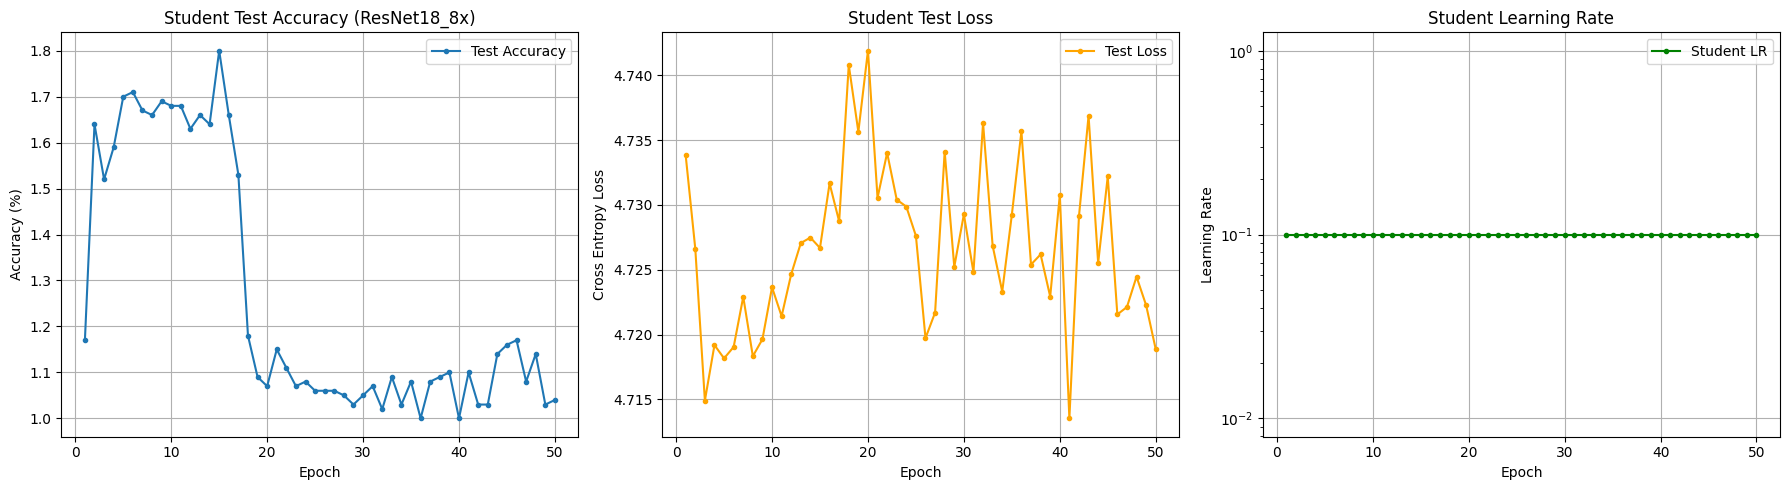


Script finished.


In [ ]:

# --- Main Execution Block ---
def main(config):
    set_seed(config["seed"])

    # --- Data Loading ---
    print(f"\nLoading {config['dataset']} test dataset...")
    try:
        transform_test = get_transforms(config['dataset'])
        # Ensure data root directory exists
        os.makedirs(config["data_root"], exist_ok=True)

        if config['dataset'] == 'cifar100':
            test_dataset_full = datasets.CIFAR100(
                root=config["data_root"], train=False, download=True, transform=transform_test
            )
        elif config['dataset'] == 'cifar10':
             test_dataset_full = datasets.CIFAR10(
                root=config["data_root"], train=False, download=True, transform=transform_test
            )
        else:
            raise ValueError(f"Unsupported dataset: {config['dataset']}")

        print(f"{config['dataset']} test dataset loaded. Samples: {len(test_dataset_full)}")
        test_loader = DataLoader(
            test_dataset_full,
            batch_size=config["test_batch_size"],
            shuffle=False,
            num_workers=min(os.cpu_count() // 2, 4), # Adjust workers based on system
            pin_memory=True if device.type == 'cuda' else False
        )
        print(f"Test loader created. Batches: {len(test_loader)}")
    except Exception as e:
        print(f"Error loading {config['dataset']} test dataset: {e}")
        exit()

    # --- Model Initialization ---
    print("\nInitializing models...")

    # --- Teacher Model ---
    print(f"Teacher Architecture: {config['teacher_model_arch']}")
    if config['teacher_model_arch'] not in MODEL_GETTERS:
         print(f"ERROR: Unknown teacher architecture: {config['teacher_model_arch']}")
         exit()
    teacher_getter = MODEL_GETTERS[config['teacher_model_arch']]
    teacher = teacher_getter(num_classes=config["num_classes"])
    count_parameters(teacher, "Teacher (Initial)") # Count before loading weights

    # Load teacher weights
    if not os.path.exists(config["teacher_weights_path"]):
        print(f"ERROR: Teacher weights not found at {config['teacher_weights_path']}")
        print("Please ensure the teacher model weights are downloaded/available and the path is correct.")
        exit()
    try:
        # Load state dict onto CPU first to avoid GPU memory issues if model defined on GPU
        state_dict = torch.load(config["teacher_weights_path"], map_location='cpu')
        # Handle potential 'module.' prefix if saved from DataParallel/DDP
        if list(state_dict.keys())[0].startswith('module.'):
            print("Removing 'module.' prefix from teacher state dict.")
            state_dict = {k[len('module.'):]: v for k, v in state_dict.items()}
        teacher.load_state_dict(state_dict)
        print("Teacher weights loaded successfully.")
    except Exception as e:
        print(f"Error loading teacher state dictionary from {config['teacher_weights_path']}: {e}")
        exit()

    teacher = teacher.to(device)
    teacher.eval()
    for param in teacher.parameters():
        param.requires_grad = False
    print("Teacher model frozen and moved to device.")
    teacher_total_params, _, _ = count_parameters(teacher, "Teacher (Frozen)")


    # --- Student Model (Dynamically selected) ---
    print(f"Student Architecture: {config['student_model_arch']}")
    if config['student_model_arch'] not in MODEL_GETTERS:
         print(f"ERROR: Unknown student architecture: {config['student_model_arch']}")
         exit()
    student_getter = MODEL_GETTERS[config['student_model_arch']]
    student = student_getter(num_classes=config["num_classes"]).to(device)
    s_total, s_trainable, _ = count_parameters(student, f"Student ({config['student_model_arch']})")

    # Calculate and display student parameter percentage relative to teacher
    if teacher_total_params > 0:
        percentage = (s_total / teacher_total_params * 100)
        print(f"  Student params as % of Teacher: {percentage:.2f}%")
    else:
        print("  Cannot calculate percentage, teacher parameter count is zero.")


    # --- Generator Model ---
    print(f"Generator Architecture: {config['generator_model']}")
    if config['generator_model'] == 'GeneratorA':
         generator = GeneratorA(
            nz=config["nz"], nc=config["channels"], img_size=config["img_size"]
         ).to(device)
    else:
        print(f"ERROR: Unknown generator architecture: {config['generator_model']}")
        exit()
    count_parameters(generator, config["generator_model"])


    # --- Optimizers and Schedulers ---
    optimizer_S = optim.SGD(
        student.parameters(),
        lr=config["lr_S"],
        momentum=config["momentum_S"],
        weight_decay=config["weight_decay_S"]
    )
    optimizer_G = optim.Adam(
        generator.parameters(),
        lr=config["lr_G"],
        betas=(0.5, 0.999) # Common GAN betas
    )
    scheduler_S = optim.lr_scheduler.MultiStepLR(
        optimizer_S,
        milestones=config["scheduler_steps"],
        gamma=config["scheduler_gamma"]
    )
    print("\nOptimizers and Scheduler initialized.")


    # --- Loss Functions ---
    # MAE (L1) Loss is used for the adversarial training between T/S logits
    # CrossEntropy Loss is used for evaluating the student on the real test dataset
    criterion_ce = nn.CrossEntropyLoss().to(device) # For evaluation
    print("Loss functions initialized (L1 for training, CE for eval).")
    # --- Evaluation Function (Simplified - No Generator needed) ---
def evaluate_model(student, test_loader, criterion_ce, device, num_classes):
    student.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar_eval = tqdm(test_loader, desc="Evaluating Model", leave=False)
        for images, labels in pbar_eval:
            images, labels = images.to(device), labels.to(device)
            outputs = student(images)
            loss = criterion_ce(outputs, labels)
            total_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_acc = (100 * correct / total_samples) if total_samples > 0 else 0
            pbar_eval.set_postfix({'Test Acc': f"{current_acc:.2f}%"})

    avg_loss = total_loss / total_samples if total_samples > 0 else 0
    accuracy = 100.0 * correct / total_samples if total_samples > 0 else 0
    cm = None
    if total_samples > 0:
        cm = plot_confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))

    print(f"Evaluation Results: Avg Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}% ({correct}/{total_samples})")
    pbar_eval.close()
    return accuracy, avg_loss, cm

# --- Plotting Function ---
def plot_confusion_matrix(cm, classes_len, save_path, title='Confusion Matrix', cmap=plt.cm.Blues, figsize=(10, 10)):
    # (Definition unchanged)
    if cm is None: print("Confusion matrix is None, skipping plot."); return
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=False, fmt='d', cmap=cmap, xticklabels=False, yticklabels=False)
    plt.title(title); plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path); print(f"Confusion matrix saved to {save_path}"); plt.close()



    # --- Training Loop ---
    print("\nStarting Adversarial Training...")
    best_accuracy = 0.0
    history = {'epoch': [], 'test_acc': [], 'test_loss': [], 'lr_S': []}
    start_training_time = time.time()
    os.makedirs(config["checkpoint_dir"], exist_ok=True) # Ensure checkpoint dir exists

    for epoch in range(1, config["epochs"] + 1):
        print(f"\n===== Epoch {epoch}/{config['epochs']} =====")
        epoch_start_time = time.time()

        # Train one epoch
        avg_loss_S_epoch, avg_loss_G_epoch = train_epoch(
            teacher=teacher,
            student=student,
            generator=generator,
            optimizer_S=optimizer_S,
            optimizer_G=optimizer_G,
            epoch=epoch,
            config=config,
            device=device
        )

        # Evaluate student on real test data
        current_accuracy, current_loss = evaluate_student(
            student=student,
            generator=generator, # Pass generator for optional visualization
            test_loader=test_loader,
            criterion_ce=criterion_ce,
            device=device,
            epoch=epoch,
            config=config
        )

        # Step the student learning rate scheduler
        scheduler_S.step()
        current_lr_S = optimizer_S.param_groups[0]['lr']

        # Log history
        history['epoch'].append(epoch)
        history['test_acc'].append(current_accuracy)
        history['test_loss'].append(current_loss)
        history['lr_S'].append(current_lr_S)

        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch} Summary: Test Acc: {current_accuracy:.2f}% | Test Loss: {current_loss:.4f} | Student LR: {current_lr_S:.6f} | Time: {epoch_time:.2f}s")

        # Checkpointing based on best test accuracy
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            print(f"  -> New best accuracy! Saving checkpoint...")
            # Save student model
            student_ckpt_path = os.path.join(
                config["checkpoint_dir"],
                # <<< Filename includes dataset and student arch >>>
                f"{config['save_prefix']}_student_best.pth"
            )
            torch.save(student.state_dict(), student_ckpt_path)
            # Save generator model (useful for resuming or analysis)
            generator_ckpt_path = os.path.join(
                config["checkpoint_dir"],
                # <<< Filename includes dataset and student arch >>>
                f"{config['save_prefix']}_generator_best.pth"
            )
            torch.save(generator.state_dict(), generator_ckpt_path)
            print(f"  -> Checkpoint saved to {config['checkpoint_dir']} with prefix '{config['save_prefix']}'")

        # Optional: Save latest checkpoint periodically (e.g., every 50 epochs)
        # if epoch % 50 == 0:
        #     print(f"  -> Saving latest checkpoint (Epoch {epoch})...")
        #     latest_student_ckpt_path = os.path.join(config["checkpoint_dir"], f"{config['save_prefix']}_student_latest.pth")
        #     latest_generator_ckpt_path = os.path.join(config["checkpoint_dir"], f"{config['save_prefix']}_generator_latest.pth")
        #     torch.save(student.state_dict(), latest_student_ckpt_path)
        #     torch.save(generator.state_dict(), latest_generator_ckpt_path)


    # --- End of Training ---
    total_training_time = time.time() - start_training_time
    print(f"\n===== Training Finished =====")
    print(f"Total Training Time: {total_training_time // 3600:.0f}h {(total_training_time % 3600) // 60:.0f}m {total_training_time % 60:.2f}s")
    print(f"Best Test Accuracy Achieved: {best_accuracy:.2f}%")
    print(f"Best student model saved with prefix: {config['save_prefix']}")

    # --- Plotting Results ---
    try:
        print("\nPlotting training history...")
        plt.figure(figsize=(18, 5))

        # Accuracy Plot
        plt.subplot(1, 3, 1)
        plt.plot(history['epoch'], history['test_acc'], label='Test Accuracy', marker='.')
        plt.title(f'Student Test Accuracy ({config["student_model_arch"]})')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend(); plt.grid(True)

        # Loss Plot
        plt.subplot(1, 3, 2)
        plt.plot(history['epoch'], history['test_loss'], label='Test Loss', color='orange', marker='.')
        plt.title('Student Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Cross Entropy Loss')
        plt.legend(); plt.grid(True)

        # Learning Rate Plot
        plt.subplot(1, 3, 3)
        plt.plot(history['epoch'], history['lr_S'], label='Student LR', color='green', marker='.')
        plt.title('Student Learning Rate')
        plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
        plt.yscale('log') # Use log scale for LR often
        plt.legend(); plt.grid(True)

        plt.tight_layout()
        # Save plot
        plot_save_path = os.path.join(config["checkpoint_dir"], f"{config['save_prefix']}_training_plots.png")
        plt.savefig(plot_save_path)
        print(f"Saved training plots to {plot_save_path}")
        plt.show() # Display the plot

    except Exception as e:
        print(f"\nCould not plot results: {e}")

    # print("\nScript finished.")
     # --- Plotting Training History ---
    # ... (Keep the history plotting code unchanged) ...
    if history['epoch']:
        try:
            print("\nPlotting training history (Accuracy vs Epoch)...")
            # ... (plotting code) ...
            plt.close() # Close plot figure
        except Exception as e:
            print(f"\nCould not plot training history: {e}")
    else:
        print("\nNo training history recorded, skipping history plot.")


    # --- Final Evaluation and Confusion Matrix Generation ---
    print("\n--- Generating Final Reports (using best saved student model) ---")
    if os.path.exists(best_student_ckpt_path):
        print(f"Loading best student model from: {best_student_ckpt_path}")
        # Need the student_getter function defined earlier based on config
        student_getter = MODEL_GETTERS[config['student_model_arch']]
        student_final = student_getter(num_classes=config["num_classes"]).to(device)
        try:
            student_final.load_state_dict(torch.load(best_student_ckpt_path, map_location=device))
            student_final.eval() # Set to eval mode AFTER loading weights

            # <<< ADDED SUMMARY CALL >>>
            print("\n--- Best Student Model Summary ---")
            try:
                # Define input size based on config
                input_size = (config["channels"], config["img_size"], config["img_size"])
                # Pass model, input size, and device (as string 'cuda' or 'cpu')
                summary(student_final, input_size=input_size, device=str(device))
            except ImportError:
                 print("torchsummary not found. Install it (`pip install torchsummary`) to get model summary.")
            except Exception as e:
                 print(f"Could not generate model summary: {e}")
            # <<< END ADDED SUMMARY CALL >>>

            # --- Now proceed with evaluation and CM plotting ---
            criterion_ce = nn.CrossEntropyLoss().to(device) # Define criterion here if not global

            # Load necessary data loaders (ensure test_loader_10 and test_loader_20 are available)
            # (Data loading part should be retained or re-run if needed)
            # Assuming test_loader_10 and test_loader_20 are defined from earlier in main

            print("\nEvaluating best model on 10% Test Split...")
            # Need a generator instance only if evaluate_student requires it (it does for viz)
            # If evaluate_student is simplified, generator isn't needed here
            generator_eval = GeneratorA(nz=config["nz"], nc=config["channels"], img_size=config["img_size"]).to(device)

            acc10, loss10, cm10 = evaluate_student(
                student=student_final, generator=generator_eval, test_loader=test_loader_10,
                criterion_ce=criterion_ce, device=device, epoch='Final', config=config, show_viz=False
            )
            plot_confusion_matrix(
                cm10, config["num_classes"],
                save_path=os.path.join(config["checkpoint_dir"], f"{config['save_prefix']}_CM_10_percent.png"),
                title=f"{config['student_model_arch']} CM (10% Test) Acc: {acc10:.2f}%"
            )

            print("\nEvaluating best model on 20% Test Split...")
            acc20, loss20, cm20 = evaluate_student(
                student=student_final, generator=generator_eval, test_loader=test_loader_20,
                criterion_ce=criterion_ce, device=device, epoch='Final', config=config, show_viz=False
            )
            plot_confusion_matrix(
                cm20, config["num_classes"],
                save_path=os.path.join(config["checkpoint_dir"], f"{config['save_prefix']}_CM_20_percent.png"),
                title=f"{config['student_model_arch']} CM (20% Test) Acc: {acc20:.2f}%"
            )

            print("\nFinal Accuracies (using Best Saved Model):")
            print(f"  10% Test Split: {acc10:.2f}%")
            print(f"  20% Test Split: {acc20:.2f}%")

        except Exception as e:
            print(f"Error during final evaluation after loading best model: {e}")

    else:
        print(f"WARNING: Best student checkpoint not found at {best_student_ckpt_path}. Skipping final evaluation, summary, and CM generation.")


    print("\nScript finished.")



# --- Argument Parser and Main Execution ---
if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Data-Free Adversarial Distillation (AKD)')

    # Add arguments corresponding to DEFAULT_CONFIG keys, allowing overrides
    # General settings
    parser.add_argument('--seed', type=int, help=f'Random seed (default: {DEFAULT_CONFIG["seed"]})')
    parser.add_argument('--data_root', type=str, help=f'Dataset root directory (default: {DEFAULT_CONFIG["data_root"]})')
    parser.add_argument('--dataset', type=str, choices=['cifar10', 'cifar100'], help=f'Dataset name (default: {DEFAULT_CONFIG["dataset"]})')
    parser.add_argument('--checkpoint_dir', type=str, help=f'Directory to save checkpoints (default: {DEFAULT_CONFIG["checkpoint_dir"]})')

    # Model settings
    parser.add_argument('--teacher_weights_path', type=str, help=f'Path to pre-trained teacher weights (REQUIRED)')
    # <<< MODIFIED: Argument to select student architecture >>>
    parser.add_argument('--student_model_arch', type=str,
                        choices=list(MODEL_GETTERS.keys()), # Select from defined ResNets
                        help=f'Student model architecture name (default: {DEFAULT_CONFIG["student_model_arch"]})')
    # parser.add_argument('--teacher_model_arch', type=str, default=DEFAULT_CONFIG['teacher_model_arch'], help='Teacher model arch') # Could be argument if needed
    parser.add_argument('--nz', type=int, help=f'Generator latent vector size (default: {DEFAULT_CONFIG["nz"]})')
    # parser.add_argument('--generator_model', type=str, default=DEFAULT_CONFIG['generator_model'], help='Generator model') # Could be argument if needed

    # Training settings
    parser.add_argument('--epochs', type=int, help=f'Number of epochs (default: {DEFAULT_CONFIG["epochs"]})')
    parser.add_argument('--iterations_per_epoch', type=int, help=f'Training iterations per epoch (default: {DEFAULT_CONFIG["iterations_per_epoch"]})')
    parser.add_argument('--batch_size', type=int, help=f'Training batch size (default: {DEFAULT_CONFIG["batch_size"]})')
    parser.add_argument('--test_batch_size', type=int, help=f'Test batch size (default: {DEFAULT_CONFIG["test_batch_size"]})')
    parser.add_argument('--k_imit_steps', type=int, help=f'Student training steps per generator step (default: {DEFAULT_CONFIG["k_imit_steps"]})')

    # Optimizer settings
    parser.add_argument('--lr_S', type=float, help=f'Student learning rate (default: {DEFAULT_CONFIG["lr_S"]})')
    parser.add_argument('--lr_G', type=float, help=f'Generator learning rate (default: {DEFAULT_CONFIG["lr_G"]})')
    parser.add_argument('--weight_decay_S', type=float, help=f'Student weight decay (default: {DEFAULT_CONFIG["weight_decay_S"]})')
    parser.add_argument('--momentum_S', type=float, help=f'Student SGD momentum (default: {DEFAULT_CONFIG["momentum_S"]})')
    parser.add_argument('--scheduler_steps', type=int, nargs='+', help=f'Epochs to decay student LR (default: {DEFAULT_CONFIG["scheduler_steps"]})')
    parser.add_argument('--scheduler_gamma', type=float, help=f'Student LR decay factor (default: {DEFAULT_CONFIG["scheduler_gamma"]})')

    # Use parse_known_args() to ignore extra arguments from environments like Colab/Jupyter
    args, unknown = parser.parse_known_args()

    # --- Configuration Setup ---
    # Start with default config
    config = DEFAULT_CONFIG.copy()

    # Create a dictionary of parsed arguments (only those explicitly passed)
    cli_args = {k: v for k, v in vars(args).items() if v is not None}

    # Override defaults with CLI arguments
    config.update(cli_args)

    # --- Set Derived Config Values AFTER merging args ---
    config["num_classes"] = 100 if config["dataset"] == 'cifar100' else 10
    config["img_size"] = 32 # Fixed for CIFAR
    config["channels"] = 3 # Fixed for CIFAR
    # Set teacher architecture based on dataset if needed (assuming fixed here)
    # config["teacher_model_arch"] = "ResNet34_8x" # Or determine dynamically
    # <<< MODIFIED: Make save prefix specific to dataset and student model >>>
    config["save_prefix"] = f"akd_{config['dataset']}_{config['student_model_arch']}"
    # Update checkpoint dir to include prefix for better organization (optional)
    # config["checkpoint_dir"] = os.path.join(config["checkpoint_dir"], config["save_prefix"])

    # Check required arguments
    if config.get('teacher_weights_path') is None or not os.path.exists(config['teacher_weights_path']):
         parser.error("Missing or invalid --teacher_weights_path. Please provide the correct path to the teacher model weights.")


    # Print final configuration
    print("\n--- Final Configuration ---")
    for key, val in config.items():
        print(f"  {key}: {val}")
    print("-------------------------")
    if unknown: # Optionally print unknown args
        print(f"Ignoring unknown arguments: {unknown}")


    # --- Run Main Function ---
    main(config)
    # <<< ================= ADDED POST-MAIN SUMMARY BLOCK ================= >>>
    print("\n--- Generating Summary for Best Saved Student Model ---")

    # Construct the path to the best student checkpoint based on the final config
    best_student_ckpt_path = os.path.join(
        config["checkpoint_dir"],
        f"{config['save_prefix']}_student_best.pth"
    )

    if os.path.exists(best_student_ckpt_path):
        print(f"Loading best student model ({config['student_model_arch']}) from: {best_student_ckpt_path}")

        # Need to instantiate the model architecture again
        try:
            student_getter = MODEL_GETTERS[config['student_model_arch']]
            # Make sure num_classes is correct based on the dataset used for training
            num_classes_final = 100 if config['dataset'] == 'cifar100' else 10
            student_summary_model = student_getter(num_classes=num_classes_final).to(device)

            # Load the saved state dictionary
            student_summary_model.load_state_dict(torch.load(best_student_ckpt_path, map_location=device))
            student_summary_model.eval() # Set to evaluation mode

            # Print the summary
            print("\n--- Best Student Model Summary ---")
            try:
                # Import torchsummary here if not imported globally earlier
                from torchsummary import summary
                input_size = (config["channels"], config["img_size"], config["img_size"])
                # Pass model, input size, and device (as string 'cuda' or 'cpu')
                summary(student_summary_model, input_size=input_size, device=str(device))
            except ImportError:
                 print("torchsummary not found. Install it (`pip install torchsummary`) to get model summary.")
            except Exception as e:
                 print(f"Could not generate model summary: {e}")

        except KeyError:
            print(f"ERROR: Model getter not found for architecture '{config['student_model_arch']}'. Cannot generate summary.")
        except Exception as e:
            print(f"Error loading or summarizing the best student model: {e}")

    else:
        print(f"WARNING: Best student checkpoint not found at {best_student_ckpt_path}. Cannot generate summary.")
        print("Ensure the training completed successfully and saved the checkpoint.")
    # <<< ======================= END OF ADDED BLOCK ======================= >>>

